# **Face Landmark Estimation with ConvNeXt U-Net Using the COFW Dataset**

This notebook presents a complete pipeline for face landmark estimation, where a **custom U-Net-based architecture** is implemented using a pre-trained [ConvNeXt Base](https://arxiv.org/pdf/2201.03545) model as the encoder (backbone). The encoder layers are fine-tuned, while the decoder layers are trained from scratch. The network is designed to predict keypoints via **heatmaps**, producing output maps of the same spatial resolution as the input images similar in structure to semantic segmentation tasks.

For this work, I use the [Caltech Occluded Faces in the Wild (COFW)](https://pdollar.github.io/files/papers/BurgosArtizzuICCV13rcpr.pdf) dataset, which consists of 1852 face images captured under realistic conditions, including severe occlusions (with an average of 23% facial occlusion) and large shape variations. The dataset is divided into 1345 training images and 507 test images. Each image contains a single face annotated with **29 keypoints**, regardless of whether they are visible or occluded, making it an ideal benchmark for basic landmark estimation tasks while introducing additional challenges due to occlusions.

## **Imports**

In [ ]:
# Install additional libraries for evaluation and visualization
!pip install torchview torchmetrics kaleido==0.2.1 -q

In [1]:
import timm
import torch
import torch.nn as nn
from torchmetrics.aggregation import MeanMetric
from torch.optim.lr_scheduler import LambdaLR
from torch.utils.data import Dataset, DataLoader
from torchsummary import summary
from torchview import draw_graph
import albumentations as A
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import plotly.graph_objects as go
from google.colab import drive
from glob import glob
from tqdm import tqdm
import requests
import cv2
import json
import os
import io

# To prevent the model architecture image from being cropped
import graphviz
graphviz.set_jupyter_format("png")

'svg'

In [2]:
# Mount Google Drive in Colab
drive.mount("/content/drive/", force_remount=True)

Mounted at /content/drive/


## **Configuration**

In [3]:
config = {
    # Paths to the preprocessed dataset and the trained model
    "data_zip_path": "/content/drive/MyDrive/Datasets/COFW.zip",
    "model_save_path": "/content/drive/MyDrive/models/FaceLandmarkEstimation_ConvNeXtBase-U-Net_COFW.pth",

    # Checkpoint
    "checkpoint_folder": "/content/drive/MyDrive/checkpoints/FaceLandmarkEstimation_ConvNeXtBase-U-Net_COFW",
    "save_freq": 25, # Frequency in epochs to save checkpoints

    # Dataset and training hyperparameters
    "epochs": 50,
    "batch_size": 8,
    "image_size": (384, 384), # Dimensions to which all images will be resized: (height, width)
    "kernel_size": (49, 49),  # Gaussian kernel size for heatmap generation
    "heatmap_sigma": 9.0, # Standard deviation for the Gaussian heatmap

    # Learning rate scheduler
    "lr0": 1e-3, # Initial learning rate
    "lrf": 1e-5, # Final learning rate
    "power": 2.0, # Polynomial decay power

    # Early stopping
    "patience": 10, # Number of epochs with no improvement before stopping
    "monitor": "val_pck", # Metric to monitor
    "mode": "max", # 'min': stops when metric stops decreasing; 'max': when it stops increasing

    "device": torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
}

# Extract directory name from zip file path
config["data_dir"] = os.path.basename(config["data_zip_path"]).split(".")[0]

## **Load Preprocessed Dataset**

The download and detailed preprocessing of the **COFW** dataset for pose estimation were completed in the following notebook: [**Preprocessing_COFW**](https://github.com/JersonGB22/PoseEstimation-TensorFlow-PyTorch/blob/main/Preprocessing/Preprocessing_COFW.ipynb).

The dataset metadata includes the following key elements:

* The total number of keypoints.
* The **skeleton**, a dictionary where the keys are the IDs of the keypoints and the values are their respective names.
* The IDs of symmetric keypoints, which are required to correctly apply **random horizontal flipping** during data augmentation.

In [4]:
# Unzip the preprocessed dataset
!unzip -q {config["data_zip_path"]}

In [5]:
# Load dataset metadata
with open(os.path.join(config["data_dir"], "metadata.json")) as f:
    metadata = json.load(f)

skeleton = metadata["skeleton"]
symmetric_kpts = metadata["symmetric_kpts"]
config["nkpts"] = metadata["nkpts"]

skeleton

{'0': 'left_eyebrow_out',
 '1': 'right_eyebrow_out',
 '2': 'left_eyebrow_in',
 '3': 'right_eyebrow_in',
 '4': 'left_eyebrow_center_top',
 '5': 'left_eyebrow_center_bottom',
 '6': 'right_eyebrow_center_top',
 '7': 'right_eyebrow_center_bottom',
 '8': 'left_eye_out',
 '9': 'right_eye_out',
 '10': 'left_eye_in',
 '11': 'right_eye_in',
 '12': 'left_eye_center_top',
 '13': 'left_eye_center_bottom',
 '14': 'right_eye_center_top',
 '15': 'right_eye_center_bottom',
 '16': 'left_eye_pupil',
 '17': 'right_eye_pupil',
 '18': 'left_nose_out',
 '19': 'right_nose_out',
 '20': 'nose_center_top',
 '21': 'nose_center_bottom',
 '22': 'left_mouth_out',
 '23': 'right_mouth_out',
 '24': 'mouth_center_top_lip_top',
 '25': 'mouth_center_top_lip_bottom',
 '26': 'mouth_center_bottom_lip_top',
 '27': 'mouth_center_bottom_lip_bottom',
 '28': 'chin'}

## **Build the Model**

The architecture of the [U-Net](https://arxiv.org/abs/1505.04597) model consists of a contraction path (encoder) to capture context and a symmetric expansion path (decoder) that allows for precise localization. To improve the model's performance, an additional convolutional block is added to both the encoder and the decoder, bringing the total number of blocks to five, compared to the four in the original U-Net model. Additionally, two **Batch Normalization** layers are incorporated into each convolutional block to help mitigate **overfitting** and **gradient vanishing**, common issues in deep neural networks. This modified U-Net architecture is generic and can be adapted to semantic segmentation tasks (using a `softmax` activation in the final layer), or, as in this case, to pose estimation tasks where the output layer uses a `sigmoid` activation, since the heatmaps are in the [0, 1] range.

![U-Net](https://lmb.informatik.uni-freiburg.de/people/ronneber/u-net/u-net-architecture.png)
*Original U-Net model*

In [ ]:
class Conv2dBlock(nn.Module):
    """
    Builds a convolutional block with two Conv2D layers, optional BatchNormalization, and ReLU activation.

    Args:
        in_channels (int): Number of input channels.
        out_channels (int): Number of output channels.
        use_bn (bool): If True, applies Batch Normalization after each convolution.
    """

    def __init__(self, in_channels, out_channels, use_bn):
        super().__init__()

        layers = [
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        ]
        if use_bn:
            layers.insert(1, nn.BatchNorm2d(out_channels))
            layers.insert(-1, nn.BatchNorm2d(out_channels))

        self.block = nn.Sequential(*layers)

    def forward(self, x):
        """Forward pass through the block."""
        return self.block(x)


class DecoderBlock(nn.Module):
    """
    A decoder block that performs upsampling using transposed convolution,
    concatenates with encoder features (skip connection), and applies a Conv2dBlock.

    Args:
        dec_channels (int): Number of channels in the decoder input.
        enc_channels (int): Number of channels from the encoder feature map.
        stride (int, optional): Upsampling factor for transposed convolution. 
        padding (int, optional): Padding for transposed convolution. 
        use_bn (bool, optional): If True, applies Batch Normalization in the convolutional block. 
    """

    def __init__(self, dec_channels, enc_channels, stride=2, padding=1, use_bn=True):
        super().__init__()
        self.conv_trans = nn.ConvTranspose2d(
            dec_channels * 2, dec_channels, kernel_size=3, stride=stride, padding=padding, output_padding=1
        )
        self.relu = nn.ReLU(inplace=True)
        self.block = Conv2dBlock(dec_channels + enc_channels, dec_channels, use_bn=use_bn)

    def forward(self, x, enc):
        """
        Forward pass through the decoder block.

        Args:
            x (torch.Tensor): Decoder input feature map.
            enc (torch.Tensor): Encoder feature map for skip connection.

        Returns:
            (torch.Tensor): Output feature map after upsampling and refinement.
        """
        x = self.relu(self.conv_trans(x))
        x = torch.cat([x, enc], dim=1)
        return self.block(x)


class ConvNeXtPoseUNet(nn.Module):
    """
    Builds a U-Net-like architecture for landmark estimation using ConvNeXt-Base
    as the encoder backbone.

    Args:
        nkpts (int): Number of keypoints to predict, corresponding to heatmap channels.
        img_channels (int, optional): Number of input image channels.
        filters (int, optional): Base number of filters for decoder blocks.
        use_bn (bool, optional): Whether to apply Batch Normalization.
    """

    def __init__(self, nkpts, img_channels=3, filters=64, use_bn=True):
        super().__init__()

        # Encoder (contracting path) 
        self.encoder = timm.create_model(
            "convnext_base",
            pretrained=True,
            features_only=True,
            out_indices=[0, 1, 2, 3]
        )

        # Decoder (expanding path) with skip connections
        self.dec4 = DecoderBlock(filters * 8, filters * 8, use_bn=use_bn)
        self.dec3 = DecoderBlock(filters * 4, filters * 4, use_bn=use_bn)
        self.dec2 = DecoderBlock(filters * 2, filters * 2, use_bn=use_bn)
        self.dec1 = DecoderBlock(filters, img_channels, stride=4, padding=0, use_bn=use_bn)

        # Output layer: generates one heatmap per keypoint
        self.output = nn.Sequential(
            nn.Conv2d(filters, nkpts, kernel_size=1),
            nn.Sigmoid()  
        )

    def forward(self, x):
        """
        Forward pass through the U-Net.

        Args:
            x (torch.Tensor): Input image tensor of shape (batch_size, channels, height, width).

        Returns:
            torch.Tensor: Predicted heatmaps of shape (batch_size, nkpts, height, width).
        """
        enc = self.encoder(x)

        dec4 = self.dec4(enc[3], enc[2])
        dec3 = self.dec3(dec4, enc[1])
        dec2 = self.dec2(dec3, enc[0])
        dec1 = self.dec1(dec2, x)

        return self.output(dec1)

In [148]:
# Initialize the U-Net model and display its architecture summary
model = ConvNeXtPoseUNet(config["nkpts"]).to(config["device"])
summary(model, input_size=(3,) + config["image_size"])

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [-1, 128, 96, 96]           6,272
       LayerNorm2d-2          [-1, 128, 96, 96]             256
          Identity-3          [-1, 128, 96, 96]               0
            Conv2d-4          [-1, 128, 96, 96]           6,400
         LayerNorm-5          [-1, 96, 96, 128]             256
            Linear-6          [-1, 96, 96, 512]          66,048
              GELU-7          [-1, 96, 96, 512]               0
           Dropout-8          [-1, 96, 96, 512]               0
          Identity-9          [-1, 96, 96, 512]               0
           Linear-10          [-1, 96, 96, 128]          65,664
          Dropout-11          [-1, 96, 96, 128]               0
              Mlp-12          [-1, 96, 96, 128]               0
         Identity-13          [-1, 128, 96, 96]               0
         Identity-14          [-1, 128,

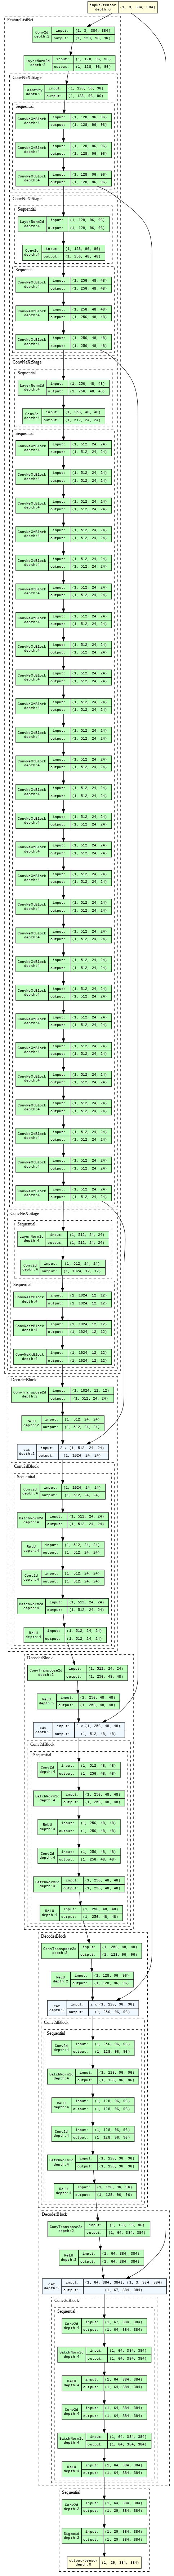

In [150]:
# Visualize the model architecture
model_graph = draw_graph(model, input_size=(1, 3) + config["image_size"], expand_nested=True, depth=4)
model_graph.visual_graph

In [ ]:
# Extract and convert image normalization parameters to tensors
model_config = model.encoder.pretrained_cfg
config["img_mean"] = torch.tensor(model_config["mean"], dtype=torch.float32)
config["img_std"] = torch.tensor(model_config["std"], dtype=torch.float32)

model_config

{'url': 'https://dl.fbaipublicfiles.com/convnext/convnext_base_22k_1k_224.pth',
 'hf_hub_id': 'timm/convnext_base.fb_in22k_ft_in1k',
 'architecture': 'convnext_base',
 'tag': 'fb_in22k_ft_in1k',
 'custom_load': False,
 'input_size': (3, 224, 224),
 'test_input_size': (3, 288, 288),
 'fixed_input_size': False,
 'interpolation': 'bicubic',
 'crop_pct': 0.875,
 'test_crop_pct': 1.0,
 'crop_mode': 'center',
 'mean': (0.485, 0.456, 0.406),
 'std': (0.229, 0.224, 0.225),
 'pool_size': (7, 7),
 'first_conv': 'stem.0'}

## **Dataset Preparation**

### **Data Augmentation**

For data augmentation, the [Albumentations](https://albumentations.ai/docs/examples/example-keypoints/) library is used a fast, flexible, and widely adopted tool in the field of computer vision. The `Affine` transformation is applied to perform **random scaling, translation, and rotation** on both the images and their corresponding keypoints. Additionally, `RandomBrightnessContrast` is used to randomly alter the **brightness and contrast** of the images.

For **random horizontal flipping**, a custom class inheriting from `HorizontalFlip` is implemented. This is necessary because the **COFW** dataset contains **symmetric keypoints**, and Albumentations does not provide native support for handling symmetry. 

Finally, it is important to note that data augmentation is applied only to the training set. Since the `Affine` rotation transformation alters the bounding box coordinates (whether using the *largest_box* or *ellipse* methods), and because model performance is evaluated with the **PCK** metric which depends on bounding boxes, evaluation must be performed exclusively on the validation and/or test sets to ensure reliable results. Moreover, this approach reduces computational overhead by avoiding unnecessary augmentation of bounding boxes.

In [ ]:
class HorizontalFlipSymmetricKeypoints(A.HorizontalFlip):
    """
    Randomly applies a horizontal flip to an image and its keypoints,
    taking into account symmetric keypoints.

    Args:
        symmetric_kpts (list[list[int, int]]): List of pairs of symmetric keypoint indices.
    """
    def __init__(self, symmetric_kpts=None, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.symmetric_kpts = symmetric_kpts

    def apply_to_keypoints(self, keypoints, **params):
        """
        Applies a horizontal flip to the image and its keypoints.

        Args:
            keypoints (np.ndarray): Array of keypoints with shape (nkpts, 2),
                where each keypoint is (x, y).

        Returns:
            (np.ndarray): Transformed keypoints with symmetric pairs swapped.
        """
        # Flip x-coordinates of keypoints
        keypoints = super().apply_to_keypoints(keypoints, **params)

        # Swap symmetric keypoint pairs
        if self.symmetric_kpts:
            for pair in self.symmetric_kpts:
                keypoints[pair] = keypoints[pair[::-1]]

        return keypoints

    def get_transform_init_args_names(self):
        """Include symmetric keypoints in Albumentations serialization."""
        return super().get_transform_init_args_names() + ("symmetric_kpts",)

In [ ]:
# Define the augmentation pipeline for pose estimation data
transforms = A.Compose(
    [
        HorizontalFlipSymmetricKeypoints(symmetric_kpts, p=0.5),
        A.Affine(
            scale=(0.8, 1.2),
            translate_percent=(-0.2, 0.2),
            rotate=(-30, 30),
            shear=(0.0, 0.0),
            p=0.6
        ),
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.3, p=0.5),
    ],
    keypoint_params=A.KeypointParams(
        format="xy",
        remove_invisible=False,
        check_each_transform=True
    ),
    p=1.0
)

### **Build Torch Training and Test Datasets**

Regarding the creation of **heatmaps** from keypoint coordinates, this is necessary because directly regressing the keypoint coordinates often leads to slower convergence. In contrast, heatmaps preserve spatial information and allow the model to infer joint positions by simply locating the **peak of the heatmap**. This technique is widely adopted in pose estimation for its stability and effectiveness.

Heatmaps are blurred using a **Gaussian filter** and normalized to avoid overfitting and ensure stable and efficient learning. The blur parameters, such as `kernel_size` and `sigma`, are determined proportionally to the image dimensions, assuming the model input and output share the same spatial resolution. Through experimentation, the following settings have produced the best results:

* Image size: (384, 384), kernel: (49, 49), sigma: 9.0
* Image size: (256, 256), kernel: (33, 33), sigma: 6.0
* Image size: (128, 128), kernel: (17, 17), sigma: 3.0

The **empirical rule** applied is that the kernel size should be approximately one-eighth of the image size (e.g., 256 / 8 = 32), and adjusted to the nearest odd number by adding 1 (32 + 1 = 33).

Larger input images allow the model to capture finer details and usually improve performance, but they also lead to longer training, evaluation, and inference times. For instance, training with (384, 384) images takes approximately 2.25 times longer than with (256, 256) images, since (384 × 384) / (256 × 256) = 2.25.

Some approaches fix the output heatmap size (e.g., 64×64), regardless of the input size. However, accurately upscaling these fixed-size heatmaps back to the original resolution is challenging and may lead to precision loss, particularly for large input images.

In [ ]:
def divide_no_nan(num, den):
  """Avoid division by zero."""
  return torch.where(den != 0, num / den, 0)

In [ ]:
def keypoints_to_heatmaps(keypoints, heatmap_size, kernel_size=(33, 33), sigma=6.0):
    """
    Converts keypoints into heatmaps using Gaussian blur.

    Args:
        keypoints (np.ndarray): Array of shape (nkpts, 2), where each row is (x, y).
        heatmap_size (tuple[int, int]): Heatmap size as (height, width).
        kernel_size (tuple[int, int], optional): Size of the Gaussian kernel (must be odd numbers).
        sigma (float, optional): Standard deviation used for Gaussian blur.

    Returns:
        (np.ndarray): Array of heatmaps with shape (nkpts, height, width).
    """

    heatmaps = []
    for x, y in keypoints.astype(np.int32):
        # Initialize an empty heatmap for the current keypoint
        heatmap = np.zeros(heatmap_size, np.float32)

        # Apply Gaussian blur
        heatmap[y, x] = 1
        heatmap = cv2.GaussianBlur(heatmap, kernel_size, sigma, borderType=cv2.BORDER_CONSTANT)
        heatmap /= heatmap.max() # Normalize heatmap to [0, 1] range

        heatmaps.append(heatmap)
    return np.stack(heatmaps, axis=0)


def heatmaps_to_keypoints(heatmaps, mode="max"):
    """
    Extracts (x, y) keypoint coordinates from heatmaps.
    Two methods are available:
        - "max": takes the position of the maximum value in the heatmap.
        - "mean": computes the center of mass (soft-argmax) as a weighted average.

    Args:
        heatmaps (tf.Tensor): Tensor of shape (batch_size, nkpts, height, width).
        mode (str, optional): One of {"max", "mean"} indicating the extraction method.

    Returns:
        (tf.Tensor): Keypoints of shape (batch_size, nkpts, 2), where each row is (x, y).
    """
    if mode not in {"max", "mean"}:
        raise ValueError("Invalid method. Use 'max' or 'mean'.")

    B, N, H, W = heatmaps.shape
    device = heatmaps.device

    if mode == "max":
        # Get index of the maximum activation for each heatmap
        indices = heatmaps.view(B, N, -1).argmax(dim=-1)
        x, y = indices % W, indices // W

    else:
        # Normalize heatmaps to form valid probability distributions
        heatmaps = divide_no_nan(heatmaps, heatmaps.sum(dim=[2, 3], keepdim=True))

        # Generate x and y coordinate grids
        xs = torch.arange(W, device=device).view(1, 1, 1, W)
        ys = torch.arange(H, device=device).view(1, 1, H, 1)

        # Compute weighted averages along each axis
        x = (heatmaps * xs).sum(dim=[2, 3])
        y = (heatmaps * ys).sum(dim=[2, 3])

    return torch.stack([x, y], dim=-1).float()

In [ ]:
class PoseDataset(Dataset):
    """
    Custom dataset for pose estimation tasks.

    Args:
        config (dict): Configuration with data and training parameters.
        split (str, optional): Either 'train' or 'test', indicating dataset partition.
        training (bool, optional): If True, applies data augmentation and generates images,
            keypoints, and heatmaps. If False, skips augmentation and also includes bounding boxes.
    """

    def __init__(self, config, split="train", training=True):
        if split not in {"train", "test"}:
            raise ValueError("Invalid dataset split. Must be 'train' or 'test'.")

        # Load image and label paths based on the split
        self.image_paths = sorted(glob(os.path.join(config["data_dir"], f"{split}/images/*.jpg")))
        self.label_paths = sorted(glob(os.path.join(config["data_dir"], f"{split}/labels/*.txt")))

        self.height, self.width = config["image_size"]
        self.config = config
        self.training = training

    def data_augmentation(self, image, keypoints):
        """
        Apply data augmentation to image and keypoints.

        Args:
            image (np.ndarray): Input image as (height, width, 3).
            keypoints (np.ndarray): Array of keypoints (nkpts, 2) in (x, y) format.

        Returns:
            (tuple[np.ndarray, np.ndarray]): Augmented image and keypoints.
        """
        transformed = transforms(image=image, keypoints=keypoints)
        keypoints_trans = transformed["keypoints"]

        # Check if all keypoints remain inside the image after transformation
        mask = (
            (keypoints_trans[:, 0] >= 0) & (keypoints_trans[:, 1] >= 0) &
            (keypoints_trans[:, 0] < self.width) & (keypoints_trans[:, 1] < self.height)
        )

        # Only accept augmentation if all keypoints are preserved
        if np.sum(mask) == self.config["nkpts"]:
            return transformed["image"], keypoints_trans

        return image, keypoints

    def __len__(self):
        """Return the total number of samples in the dataset."""
        return len(self.image_paths)

    def __getitem__(self, idx):
        """
        Load and process a single sample.

        Args:
            idx (int): Index of the sample to retrieve.

        Returns:
            (dict[str, torch.Tensor]): Contains images, heatmaps, and keypoints.
                If not in training mode, also yields bounding boxes.
        """
        # Load and resize image
        image = Image.open(self.image_paths[idx]).convert("RGB")
        image = np.array(image.resize((self.width, self.height)))

        # Load label: [xmin, ymin, width, height, x1, y1, ..., xn, yn]
        label = np.loadtxt(self.label_paths[idx], dtype=np.float32)

        # Extract and denormalize keypoints
        keypoints = label[4:].reshape(-1, 2)
        keypoints[:, 0] *= self.width
        keypoints[:, 1] *= self.height

        # Apply augmentation if training
        if self.training:
            image, keypoints = self.data_augmentation(image, keypoints)

        # Generate heatmaps from keypoints using Gaussian blur
        keypoints = keypoints.astype(np.int32)
        heatmaps = keypoints_to_heatmaps(
            keypoints, (self.height, self.width),
            self.config["kernel_size"], self.config["heatmap_sigma"]
        )

        # Convert keypoints and heatmaps to tensors
        keypoints = torch.tensor(keypoints, dtype=torch.float32)
        heatmaps = torch.tensor(heatmaps, dtype=torch.float32)

        # Convert image to tensor and normalize
        image = torch.tensor(image, dtype=torch.float32)
        image = ((image / 255) - self.config["img_mean"]) / self.config["img_std"]
        image = image.permute(2, 0, 1)

        data = {"images": image, "heatmaps": heatmaps, "keypoints": keypoints}

        # Extract and denormalize bounding box if configured
        if not self.training:
            data["bboxes"] = torch.tensor([
                label[0] * self.width,
                label[1] * self.height,
                label[2] * self.width,
                label[3] * self.height
            ], dtype=torch.float32)

        return data

In [161]:
train_dataset = PoseDataset(config, "train")
test_dataset = PoseDataset(config, "test", training=False)

num_workers = os.cpu_count() // 2
print(len(train_dataset), len(test_dataset), num_workers)

train_dataset = DataLoader(
    train_dataset,
    batch_size=config["batch_size"],
    shuffle=True,
    num_workers=num_workers,
    pin_memory=True
)
test_dataset = DataLoader(
    test_dataset,
    batch_size=config["batch_size"],
    shuffle=False,
    num_workers=num_workers,
    pin_memory=True
)

config["total_steps"] = len(train_dataset) * config["epochs"]

1167 500 1


In [152]:
# Take a batch from the test dataset
samples = next(iter(test_dataset))

for k, v in samples.items():
    print(f"{k}: {v.shape}")

images: torch.Size([8, 3, 384, 384])
heatmaps: torch.Size([8, 29, 384, 384])
keypoints: torch.Size([8, 29, 2])
bboxes: torch.Size([8, 4])


In [162]:
# Take a batch from the training dataset
samples = next(iter(train_dataset))

for k, v in samples.items():
    print(f"{k}: {v.shape}")

images: torch.Size([8, 3, 384, 384])
heatmaps: torch.Size([8, 29, 384, 384])
keypoints: torch.Size([8, 29, 2])


### **Pose Visualization Utility Class**

In [ ]:
class PoseVisualizer():
    """
    Utility for visualizing pose estimation results: keypoints and heatmaps.

    Args:
        config (dict): Configuration with data and training parameters.
    """
    def __init__(self, config):
        self.config = config

    def draw_pose(self, ax, keypoints, show_points=True, show_kpts_ids=True):
        """
        Draws keypoints and skeleton on a given Matplotlib Axes.

        Args:
            ax (plt.Axes): Matplotlib axes to draw on.
            keypoints (np.ndarray): Array of shape (nkpts, 2) with (x, y).
            show_points (bool, optional): Whether to plot keypoint markers.
            show_kpts_ids (bool, optional): Whether to annotate keypoints with their indices.
        """
        for id, (x, y) in enumerate(keypoints):
            # Draw keypoint as a circle
            if show_points:
                ax.scatter(
                    x, y,
                    facecolors="cyan",
                    edgecolors="blue",
                    linewidths=1,
                    s=(70 if id > 9 else 60) if show_kpts_ids else 20,
                    zorder=1
                )

            # Display keypoint ID as label
            if show_kpts_ids:
                ax.text(
                    x, y, str(id),
                    color="black" if show_points else "white",
                    fontsize=5 if show_points else 5.4,
                    fontweight="bold", ha="center", va="center", zorder=2
                )

    def download_images(self, urls, image_size=None):
        """
        Downloads and optionally resizes images from URLs.

        Args:
            urls (list[str]): List of image URLs.
            image_size (tuple[int, int], optional): Desired (height, width). If provided, images are resized.

        Returns:
            (np.ndarray): Batch of images as a NumPy array of shape (N, H, W, 3).
        """
        images = []
        for url in urls:
            response = requests.get(url)
            image = Image.open(io.BytesIO(response.content)).convert("RGB")
            if image_size:
                image = image.resize(image_size[::-1])

            images.append(np.array(image))
        return np.stack(images)

    def plot_keypoints_heatmaps(
            self, images, keypoints, heatmaps=None, config=None, n_rows=2, alpha=0.6,
            random=True, show_points=True, show_kpts_ids=True, save_path=None
    ):
        """
        Displays images with overlayed keypoints and summed heatmaps side by side.

        Args:
            images (np.ndarray): Batch of images (N, H, W, 3).
            keypoints (np.ndarray): Array of keypoints (N, nkpts, 2).
            heatmaps (np.ndarray, optional): Precomputed heatmaps (N, nkpts, H, W). If None, computed on the fly.
            config (dict): Configuration with data and training parameters. Required if heatmaps is None.
            n_rows (int, optional): Number of rows to display.
            alpha (float, optional): Transparency for heatmap overlay.
            random (bool, optional): Shuffle sample order if True.
            show_points (bool, optional): Whether to plot keypoint markers.
            show_kpts_ids (bool, optional): Whether to annotate keypoints with their indices.
            save_path (str, optional): File path to save the figure. If None, figure is not saved.
        """
        indices = np.arange(len(images))
        if random:
            np.random.shuffle(indices)

        fig, axes = plt.subplots(n_rows, 2, figsize=(9.6, 4.8 * n_rows))
        axes = np.array(axes).reshape(n_rows, 2)

        for col, title in enumerate(["Keypoints", "Heatmaps"]):
            axes[0, col].set_title(title, fontsize=9)

        for i in range(n_rows):
            idx = indices[i]
            image = images[idx]
            kpts = keypoints[idx]

            # Compute heatmaps if not provided
            if heatmaps is not None:
                hmaps = heatmaps[idx]
            else:
                hmaps = keypoints_to_heatmaps(kpts, config["image_size"], config["kernel_size"], config["heatmap_sigma"])

            # Combine and normalize heatmaps for visualization as a single overlay
            hmaps = hmaps.sum(axis=0)
            hmaps = (hmaps - hmaps.min()) / hmaps.max()

            ax = axes[i, 0]
            ax.imshow(image)
            self.draw_pose(ax, kpts, show_points, show_kpts_ids)
            ax.axis("off")

            ax = axes[i, 1]
            ax.imshow(image)
            ax.imshow(hmaps, cmap="jet", alpha=alpha)
            ax.axis("off")

        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, bbox_inches="tight", pad_inches=0)
        plt.show()

    def plot_keypoints(
            self, images, keypoints, keypoints_pred=None, bboxes=None, diagonals=None, metric=None,
            n_rows=2, n_cols=2, random=True, show_points=True, show_kpts_ids=True, save_path=None
    ):
        """
        Shows true vs predicted keypoints and optionally computes metrics on each sample.

        Args:
            images (np.ndarray): Batch of images (N, H, W, 3).
            keypoints (np.ndarray): Ground-truth keypoints (N, nkpts, 2).
            keypoints_pred (np.ndarray, optional): Predicted keypoints (N, nkpts, 2). If None, only true keypoints are shown.
            diagonals (np.ndarray, optional): Array of shape (N,) containing bounding box diagonals.
            metric (PCKMetric, optional): Metric object used to compute PCK.
            n_rows (int, optional): Number of rows.
            n_cols (int, optional): Number of columns when keypoints_pred is None.
            random (bool, optional): Shuffle sample order if True.
            show_points (bool, optional): Whether to plot keypoint markers.
            show_kpts_ids (bool, optional): Whether to annotate keypoints with their indices.
            save_path (str, optional): File path to save the figure. If None, figure is not saved.
        """

        indices = np.arange(len(images))
        if random:
            np.random.shuffle(indices)

        if keypoints_pred is None:
            fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.8 * n_cols, 4.8 * n_rows))
            axes = axes.flatten() if (n_rows * n_cols) > 1 else [axes]

            for i, ax in enumerate(axes):
                idx = indices[i]
                image = images[idx]
                kpts = keypoints[idx]

                ax.imshow(image)
                ax.axis("off")
                self.draw_pose(ax, kpts, show_points, show_kpts_ids)

                if bboxes is not None:
                    bbox = bboxes[idx]
                    rect = patches.Rectangle((bbox[0], bbox[1]), bbox[2], bbox[3], linewidth=1.75, edgecolor="red", facecolor="none")
                    ax.add_patch(rect)

        else:
            fig, axes = plt.subplots(n_rows, 2, figsize=(9.6, 4.8 * n_rows))
            axes = np.array(axes).reshape(n_rows, 2)

            for col, title in enumerate(["True Keypoints", "Pred Keypoints"]):
                axes[0, col].set_title(title, fontsize=9)

            for i in range(n_rows):
                idx = indices[i]
                image = images[idx]
                kpts_true = keypoints[idx]
                kpts_pred = keypoints_pred[idx]

                ax = axes[i, 0]
                ax.imshow(image)
                ax.axis("off")
                self.draw_pose(ax, kpts_true, show_points, show_kpts_ids)

                ax = axes[i, 1]
                ax.imshow(image)
                ax.axis("off")
                self.draw_pose(ax, kpts_pred, show_points, show_kpts_ids)

                # Compute and display the result of the metric
                if (diagonals is not None) and (metric is not None):
                    metric.reset()
                    metric.update(
                        torch.tensor(kpts_pred[None, :], dtype=torch.float32),
                        torch.tensor(kpts_true[None, :], dtype=torch.float32),
                        torch.tensor([diagonals[idx]], dtype=torch.float32),
                    )

                    shape = image.shape
                    ax.text(
                        x=shape[1] / 2, y=shape[0],
                        s=f"{metric.name.upper()}: {metric.compute().item():.3f}",
                        fontsize=5.41, fontweight="bold", ha="center", va="top",
                    )

                if bboxes is not None:
                    bbox = bboxes[idx]
                    rect1 = patches.Rectangle((bbox[0], bbox[1]), bbox[2], bbox[3], linewidth=1.75, edgecolor="red", facecolor="none")
                    rect2 = patches.Rectangle((bbox[0], bbox[1]), bbox[2], bbox[3], linewidth=1.75, edgecolor="red", facecolor="none")
                    axes[i, 0].add_patch(rect1)
                    axes[i, 1].add_patch(rect2)

        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, bbox_inches="tight", pad_inches=0)
        plt.show()

    def plot_from_urls(
            self, model, urls, image_size, n_rows=2, n_cols=2, random=False,
            show_points=True, show_kpts_ids=True, save_path=None
    ):
        """
        Downloads images, runs model inference, and visualizes predicted keypoints.

        Args:
            model (nn.Module): Landmark estimation model.
            urls (list[str]): List of image URLs.
            image_size (tuple[int, int]): (height, width) to resize images.
            n_rows (int, optional): Number of display rows.
            n_cols (int, optional): Number of display columns.
            random (bool, optional): Shuffle display order if True.
            show_points (bool, optional): Whether to plot keypoint markers.
            show_kpts_ids (bool, optional): Whether to annotate keypoints with their indices.
            save_path (str, optional): File path to save the figure. If None, figure is not saved.
        """
        images = self.download_images(urls[:n_rows * n_cols], image_size)
        inputs = torch.tensor(images, dtype=torch.float32)
        inputs = ((inputs / 255) - self.config["img_mean"]) / self.config["img_std"]

        model.eval()
        with torch.no_grad():
            heatmaps = model(inputs.permute(0, 3, 1, 2).to(self.config["device"]))
        keypoints = heatmaps_to_keypoints(heatmaps).cpu().numpy()

        self.plot_keypoints(
            images, keypoints, n_rows=n_rows, n_cols=n_cols, random=random,
            show_points=show_points, show_kpts_ids=show_kpts_ids,
            save_path=save_path
        )

In [42]:
visualizer = PoseVisualizer(config)

In [163]:
images = ((samples["images"].permute(0, 2, 3, 1) * config["img_std"]) + config["img_mean"]).numpy()
heatmaps = samples["heatmaps"].numpy()
keypoints = samples["keypoints"].numpy()
#bboxes = samples["bboxes"].numpy()

As shown below, using the **'max'** mode to convert heatmaps into keypoint coordinates is highly accurate and will be used in this project to achieve the best possible results. Furthermore, in the loss function implemented later to estimate keypoint visibility, the maximum value of each heatmap is taken into account. 

In [164]:
np.all(keypoints == heatmaps_to_keypoints(samples["heatmaps"]).numpy())

np.True_

In the following example, the number of pixels with values greater than zero in each heatmap with non-zero visibility is equal to the product of the kernel dimensions (in this case, 49 × 49 = 2401), except when the keypoints are located very close to the edges of the image.

In [169]:
idx = 2
np.sum(heatmaps[idx] > 0, axis=(1, 2))

array([2401, 1960, 2401, 2401, 2401, 2401, 2009, 2401, 2401, 2401, 2401,
       2401, 2401, 2401, 2401, 2401, 2401, 2401, 2401, 2401, 2401, 2401,
       2401, 2401, 2401, 2401, 2401, 2401, 2401])

In [170]:
keypoints[idx]

array([[ 57., 101.],
       [217.,  15.],
       [114.,  67.],
       [164.,  39.],
       [ 81.,  70.],
       [ 85.,  78.],
       [188.,  16.],
       [193.,  24.],
       [ 89., 125.],
       [226.,  56.],
       [131., 106.],
       [189.,  75.],
       [104., 104.],
       [112., 120.],
       [203.,  55.],
       [209.,  70.],
       [110., 114.],
       [206.,  65.],
       [151., 152.],
       [211., 119.],
       [177., 125.],
       [183., 137.],
       [155., 207.],
       [247., 158.],
       [198., 166.],
       [203., 173.],
       [210., 186.],
       [216., 196.],
       [234., 226.]], dtype=float32)

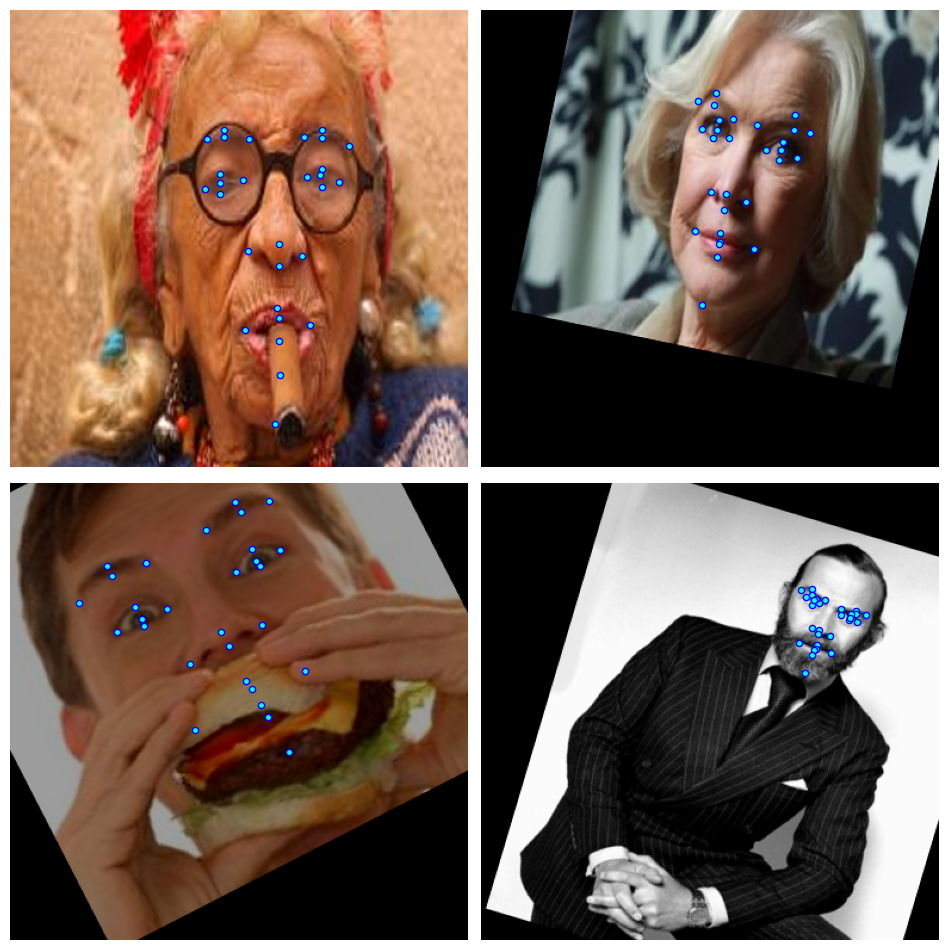

In [167]:
visualizer.plot_keypoints(images, keypoints, random=False, show_kpts_ids=False)

## **Implement Pose Metric and Loss Function**

#### **[Percentage of Correct Keypoints (PCK)](https://www.albany.edu/faculty/mchang2/files/2018_10_ICIP_Pose.pdf)**

Evaluates the percentage of keypoints correctly localized within a threshold normalized by the object's scale.

**Formula:**

$$
{PCK}(\alpha) =
\frac{1}{M} \, \frac{1}{N} \,
\sum_{m=1}^{M} \sum_{n=1}^{N}
\mathbb{I}\left(\frac{d_n}{H_m} < \alpha\right)
$$

where:

* $M$ is the number of images.
* $N$ is the number of keypoints per image.
* $d_n$ is the Euclidean distance between the predicted and ground-truth keypoint for point $n$.
* $H_m$ is the normalization factor for image $m$. In this case, the diagonal of the face bounding box is used for a more general comparison with other pose estimation and landmark estimation tasks.
* $\alpha$ is the tolerance threshold to consider a keypoint as correctly predicted. Since this task involves face landmark estimation, a stricter value is required; thus, $\alpha = 0.05$ (5%) is used.
* $\mathbb{I}$ is the indicator function, which equals 1 if the condition is true, and 0 otherwise.


**The metric ranges from 0 to 1, with 1 indicating perfect performance.**

In [ ]:
# Define PCK alpha threshold
config["alpha"] = 0.05

In [ ]:
class PCKMetric():
    """
    Computes the Percentage of Correct Keypoints (PCK) metric, normalized
    by the diagonal length of the object's bounding box. Assumes one object per image.

    Args:
        alpha (float): Threshold for considering a keypoint as correctly predicted.
        device (str, optional): Device for computation.
        name (str, optional): Name of the metric.
    """

    def __init__(self, alpha=0.1, device="cpu", name="pck"):
        self.alpha = torch.tensor(alpha, dtype=torch.float32)
        self.device = device
        self.name = name

        self.total_correct = torch.zeros((), dtype=torch.float32, device=self.device)
        self.total = torch.zeros((), dtype=torch.float32, device=self.device)

    def update(self, kpts_pred, kpts_true, diagonals):
        """
        Accumulates the PCK over a batch.

        Args:
            kpts_pred (torch.Tensor): Predicted keypoints with of shape (batch_size, nkpts, 2).
            kpts_true (torch.Tensor): Ground-truth keypoints the same shape as kpts_pred.
            diagonals (torch.Tensor): Diagonals of the bounding boxes, shape (batch_size,).
        """
        # Compute Euclidean distance
        d = (kpts_true - kpts_pred).square().sum(dim=2).sqrt() # (B, nkpts)

        # Compute correct prediction mask
        correct_mask = ((d / diagonals[:, None]) < self.alpha).float()

        self.total_correct += correct_mask.sum()
        self.total += correct_mask.numel()

    def compute(self):
        """Returns the PCK."""
        return divide_no_nan(self.total_correct, self.total)

    def reset(self):
        """Resets the internal state of the metric."""
        self.total_correct.zero_()
        self.total.zero_()

#### **$L^2$ Soft Jaccard Loss**

In pose estimation tasks, the predicted heatmaps represent probability distributions over the expected locations of each keypoint. To effectively compare predicted and ground truth heatmaps, it is crucial to use a loss function that is sensitive to both the shape and intensity of these distributions.

The **$L^2$ Soft Jaccard Loss**, inspired by the Jaccard Index (also known as Intersection over Union, IoU) and introduced in the context of deep learning by [Berman et al., 2017](https://arxiv.org/pdf/1606.04797), has proven to be particularly effective. Its formulation, adapted for continuous heatmap representations, is differentiable and based on the squared $L^2$ norm. This makes it especially suitable for capturing spatial relationships between predicted and ground truth distributions. The loss has been further refined and successfully applied in later works such as [Nie et al., 2020](https://arxiv.org/pdf/2010.13499) and [Tang et al., 2023](https://arxiv.org/pdf/2302.05666), particularly in semantic segmentation tasks a domain that shares key structural similarities with pose estimation.

Unlike the **Mean Squared Error (MSE)** loss, which measures pixel-wise differences, the Soft Jaccard Loss evaluates the global overlap between predicted and ground truth heatmaps. Since heatmaps are soft distributions (with values between 0 and 1 rather than binary masks), the squared $L^2$ norm in the denominator naturally emphasizes higher intensity values near the center of the keypoint while diminishing low activation areas. This effect mimics a confidence weighted loss enhancing peak localization without requiring explicit reweighting, as is often necessary with MSE.

Moreover, in practice, pose estimation models trained with MSE tend to converge very slowly. In contrast, the $L^2$ Soft Jaccard Loss leads to faster convergence and superior localization performance, making it a better choice in virtually every aspect.

**Formula:**

$$
\mathcal{L}_{\text{L2SJ}} = 1 - \frac{\sum y \hat{y}}{\sum y^2 + \sum \hat{y}^2 - \sum y \hat{y}}
$$

where:

* $y$ denotes the ground truth heatmaps.
* $\hat{y}$ denotes the predicted heatmaps.

In [ ]:
def PoseLoss(y_pred, y_true):
    """
    Computes L2 Soft Jaccard Loss for heatmap similarity.

    Args:
        y_pred (torch.Tensor): Predicted heatmaps of shape (batch_size, nkpts, height, width).
        y_true (torch.Tensor): Ground truth heatmaps with the same shape as y_pred.

    Returns:
        (torch.Tensor): A scalar representing the average loss over the batch.
    """
    intersect_area = (y_true * y_pred).sum(dim=[2, 3])
    combined_area = (y_true.square() + y_pred.square()).sum(dim=[2, 3])
    loss = 1 - divide_no_nan(intersect_area, combined_area - intersect_area)
    return loss.mean()

## **Train the Model**

In [ ]:
class PoseTrainer():
    """
    High-level training loop for pose estimation models using PyTorch.
    This trainer handles supervised training with heatmap regression,
    validation, prediction, learning rate scheduling, checkpointing,
    and early stopping. It also integrates the PCK metric for evaluation.

    Args:
        model (nn.Module): Pose estimation model that outputs heatmaps.
        config (dict): Configuration with data and training parameters.
    """

    def __init__(self, model, config):
        self.model = model
        self.config = config
        self.device = config["device"]

        # Initialize metrics, optimizer and loss function
        self.pck_metric = PCKMetric(config["alpha"], self.device)
        self.loss_metric = MeanMetric().to(self.device)
        self.criterion = PoseLoss
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=config["lr0"])
        self.scheduler = self.build_scheduler(
            self.optimizer,
            config["lr0"],
            config["total_steps"],
            config["lrf"],
            config["power"]
        )

    def build_scheduler(self, optimizer, lr0, decay_steps, lrf, power):
        """
        Build a polynomial learning rate scheduler.

        Args:
            optimizer (torch.optim.Optimizer): Optimizer to schedule.
            lr0 (float): Initial learning rate.
            decay_steps (int): Number of steps until reaching final LR.
            lrf (float): Final learning rate.
            power (float): Polynomial decay exponent.

        Returns:
            (torch.optim.lr_scheduler.LambdaLR): Polynomial LR scheduler.
        """
        def polynomial_decay(step):
            step = min(step, decay_steps)
            decayed_lr = (lr0 - lrf) * ((1 - (step / decay_steps)) ** power) + lrf
            return decayed_lr / lr0

        return LambdaLR(optimizer, lr_lambda=polynomial_decay)

    def run_epoch(self, dataset, phase="train", training=True):
        """
        Runs one epoch of training or validation.

        Args:
            dataset (torch.utils.data.DataLoader): Batched dataset.
            phase (str, optional): 'train', 'val' or 'test'.
            training (bool, optional): True for training, False for evaluation.

        Returns:
            (dict[str, float]): Metric results from the epoch.
        """
        # Switch model mode depending on phase
        self.model.train() if training else self.model.eval()

        # Reset metrics at epoch start
        self.loss_metric.reset()
        if not training:
            self.pck_metric.reset()

        desc = phase.capitalize().rjust(5)
        phase = "" if phase == "train" else phase + "_"

        with tqdm(dataset, desc=desc, total=len(dataset)) as pbar:
            for batch in pbar:
                images = batch["images"].to(self.device)
                heatmaps = batch["heatmaps"].to(self.device)

                # Enable gradient computation if the model is in training mode
                with torch.set_grad_enabled(training):
                    if training:
                        self.optimizer.zero_grad()
                    
                    # Forward pass
                    heatmaps_pred = self.model(images)
                    loss = self.criterion(heatmaps_pred, heatmaps)

                    # Backward + optimizer step
                    if training:
                        loss.backward()
                        self.optimizer.step()
                        self.scheduler.step()
                
                # Update loss metric
                self.loss_metric.update(loss, weight=len(heatmaps))
                results = {f"{phase}loss": self.loss_metric.compute().item()}

                if not training:
                    # Convert predicted heatmaps to keypoints
                    keypoints = batch["keypoints"].to(self.device)
                    keypoints_pred = heatmaps_to_keypoints(heatmaps_pred.detach())

                    # Compute bbox diagonals and update PCK metric
                    diagonals = torch.linalg.norm(batch["bboxes"][:, 2:].to(self.device), dim=1)
                    self.pck_metric.update(keypoints_pred, keypoints, diagonals)
                    results[f"{phase}pck"] = self.pck_metric.compute().item()

                if training:
                    results["lr"] = self.scheduler.get_last_lr()[0]

                pbar.set_postfix(results)

        return results

    def train(self, train_dataset, val_dataset, resume_checkpoint=False):
        """
        Full training loop with validation, checkpointing, and early stopping.

        Args:
            train_dataset (torch.utils.data.DataLoader): Training dataset.
            val_dataset (torch.utils.data.DataLoader): Validation dataset.
            resume_checkpoint (bool, optional): Whether to resume from the last checkpoint.

        Returns:
            (pd.DataFrame): Training history.
        """
        checkpoint_folder = self.config["checkpoint_folder"]
        best_weights_path = os.path.join(checkpoint_folder, "best_weights.pth")
        monitor = self.config["monitor"]
        mode = self.config["mode"]
        epochs = self.config["epochs"]

        # Restore previous checkpoint, history, best metric, and wait if resume is enabled
        if resume_checkpoint:
            history = pd.read_csv(os.path.join(checkpoint_folder, "history.csv"))
            checkpoint = torch.load(os.path.join(checkpoint_folder, f"epoch_{len(history)}.pth"), weights_only=True)

            self.model.load_state_dict(checkpoint["model"])
            self.optimizer.load_state_dict(checkpoint["optimizer"])
            self.scheduler.load_state_dict(checkpoint["scheduler"])
            del checkpoint

            values = history[monitor]
            best_metric = values.min() if mode == "min" else values.max()
            wait = len(history) - (values.idxmin() if mode == "min" else values.idxmax()) - 1

        else:
            os.makedirs(checkpoint_folder, exist_ok=True)
            history = pd.DataFrame(columns=[
                "loss", "lr",
                "val_loss", "val_pck"
            ])

            best_metric = float("inf") if mode == "min" else float("-inf")
            wait = 0

        for epoch in range(len(history) + 1, epochs + 1):
            print(f"Epoch {epoch}/{epochs}")

            # Run training and validation
            train_results = self.run_epoch(train_dataset, "train", training=True)
            val_results = self.run_epoch(val_dataset, "val", training=False)
            print()

            # Update history
            train_results.update(val_results)
            history.loc[len(history)] = train_results

            # Early stopping logic
            current = val_results[monitor]
            improved = current < best_metric if mode == "min" else current > best_metric
            if improved:
                torch.save(self.model.state_dict(), best_weights_path)
                best_metric = current
                wait = 0
            else:
                wait += 1

            # Save periodic checkpoint
            if epoch % self.config["save_freq"] == 0:
                torch.save(
                {
                    "model": self.model.state_dict(),
                    "optimizer": self.optimizer.state_dict(),
                    "scheduler": self.scheduler.state_dict()
                },
                os.path.join(checkpoint_folder, f"epoch_{epoch}.pth")
            )

            # Save history regularly or at end
            if (epoch == epochs) or (epoch % self.config["save_freq"] == 0) or (wait >= self.config["patience"]):
                history.to_csv(os.path.join(checkpoint_folder, "history.csv"), index=False)

            # Trigger early stopping if no improvement for 'patience' epochs
            if wait >= self.config["patience"]:
                print(f"Early stopping triggered after {wait} epochs without improvement.")
                break

        # Restore best model and save final weights
        self.model.load_state_dict(torch.load(best_weights_path, weights_only=True))
        torch.save(self.model.state_dict(), self.config["model_save_path"])
        return history

    def eval(self, dataset, phase="val"):
        """
        Runs validation on a dataset.

        Args:
            dataset (torch.utils.data.DataLoader): Evaluation dataset.
            phase (str, optional): 'val' or 'test'.

        Returns:
            (dict[str, float]): Evaluation metrics.
        """
        return self.run_epoch(dataset, phase, training=False)

    def predict(self, dataset, return_kpts=True, steps=None):
        """
        Generates predictions from the model.

        Args:
            dataset (torch.utils.data.DataLoader): Dataset to predict on.
            return_kpts (bool, optional): Whether to convert heatmaps to keypoints.
            steps (int, optional): Number of steps to run, or None for full dataset.

        Returns:
            (torch.Tensor): Concatenated predictions from all batches.
        """
        self.model.eval()
        all_preds = []

        with torch.no_grad():
            with tqdm(total=steps or len(dataset)) as pbar:
                for i, batch in enumerate(dataset, 1):
                    preds = self.model(batch["images"].to(self.device))
                    if return_kpts:
                        preds = heatmaps_to_keypoints(preds)
                    all_preds.append(preds.cpu())

                    pbar.update(1)
                    if i == steps:
                        break

        return torch.concat(all_preds, axis=0)

In [ ]:
trainer = PoseTrainer(model, config)
history = trainer.train(train_dataset, test_dataset, resume_checkpoint=False)

Epoch 1/50


  Val: 100%|██████████| 63/63 [01:01<00:00,  1.03it/s, val_loss=0.5, val_pck=0.62]



Epoch 2/50


  Val: 100%|██████████| 63/63 [00:57<00:00,  1.09it/s, val_loss=0.299, val_pck=0.824]



Epoch 3/50


...


Epoch 42/50


  Val: 100%|██████████| 63/63 [00:57<00:00,  1.10it/s, val_loss=0.121, val_pck=0.957]



Epoch 43/50


  Val: 100%|██████████| 63/63 [00:59<00:00,  1.07it/s, val_loss=0.12, val_pck=0.957]



Early stopping triggered after 10 epochs without improvement.


## **Model Evaluation**

### **Training and Validation Curves**

In [ ]:
#history = pd.read_csv(os.path.join(config["checkpoint_folder"], "history.csv"))
idxmax = history[config["monitor"]].idxmax()
history = history.rename(columns={
    "loss": "Loss",
    "val_loss": "Val Loss",
    "val_pck": f"Val PCK@{config['alpha']}"
})

In [ ]:
def plot_metrics(history, metrics=None, idxmax=None, renderer=None):
    """
    Plots the evolution of training and validation metrics over epochs using Plotly.

    Args:
        history (pd.DataFrame): DataFrame containing the training history with one column per metric.
        metrics (list[str], optional): List of metric names to plot. If None, all columns will be plotted.
        idxmax (int, optional): Index of the best epoch based on the monitored metric. If None, no vertical line is shown.
        renderer (str, optional): Renderer to use for Plotly (e.g., 'notebook', 'colab', 'png').
    """
    epochs = len(history)
    if metrics is None:
        metrics = history.columns.tolist()

    list_epochs = np.arange(1, epochs + 1)
    fig = go.Figure()

    for metric in metrics:
        if metric not in history.columns:
            raise ValueError(f"Metric '{metric}' not found in history columns.")

        # Add line plot for the current metric
        fig.add_trace(go.Scatter(
            x=list_epochs,
            y=history[metric],
            name=metric,
            mode="lines",
            line=dict(width=2)
        ))

    # Add vertical line for early stopping point, if provided
    if idxmax is not None:
        fig.add_vline(
            x=idxmax + 1,
            line=dict(color="red", width=2, dash="dash"),
            annotation_text="Early Stopping",
            annotation_position="top left",
            annotation=dict(font_size=12, font_color="red")
        )

    # Determine whether we're plotting losses, metrics, or mixed
    is_loss = all("loss" in m.lower() for m in metrics)
    is_metric = all("loss" not in m.lower() for m in metrics)

    title_text = "Loss Evolution" if is_loss else (
        "Metric Evolution" if is_metric else "Loss and Metric Evolution"
    )
    yaxis_text = "Loss" if is_loss else (
        "Metric" if is_metric else "Value"
    )

    # Axis and layout customization
    fig.update_layout(
        title=title_text,
        title_font=dict(size=18),
        title_x=0.5,
        xaxis_title="Epoch",
        yaxis_title=yaxis_text,
        width=1000,
        height=500,
        showlegend=True
    )

    fig.show(renderer=renderer)

In [ ]:
# Interactive graphics
plot_metrics(history, history.columns[[0, 2]], idxmax)
plot_metrics(history, history.columns[3:], idxmax)

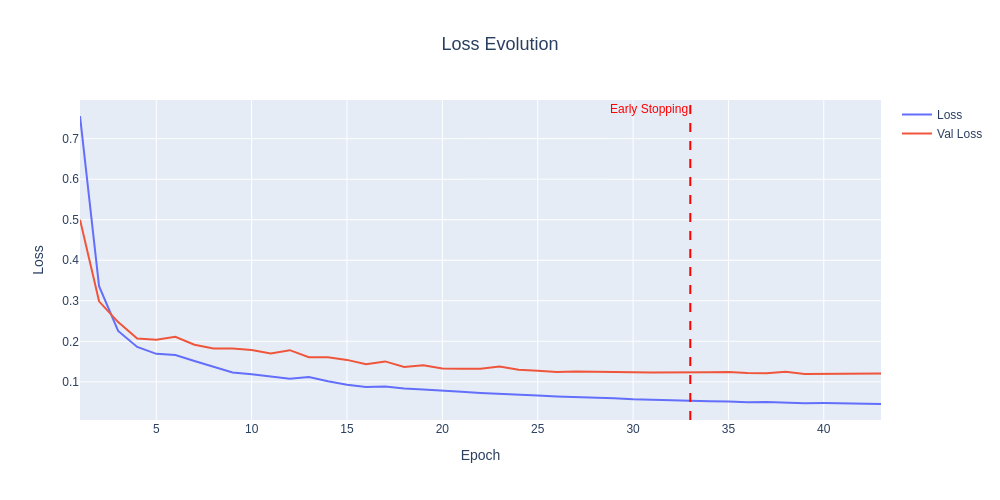

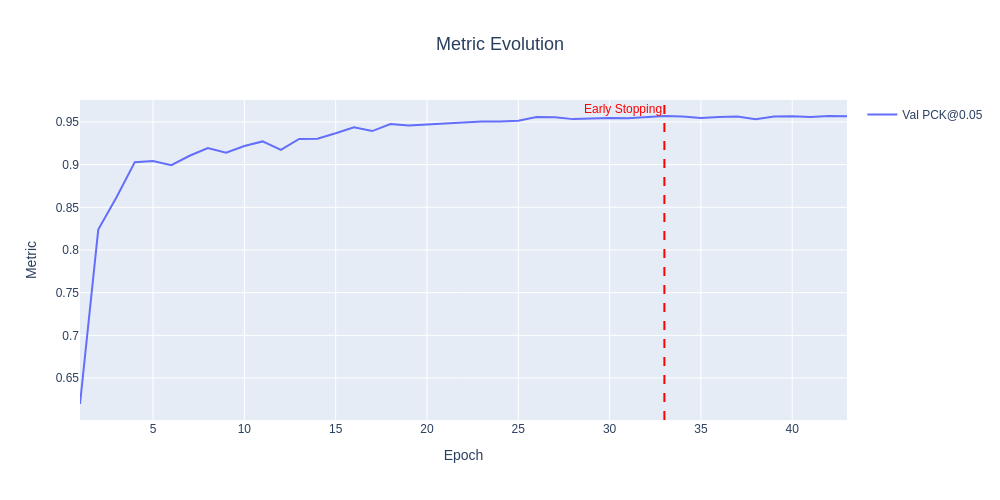

In [ ]:
# Static images for GitHub
plot_metrics(history, history.columns[[0, 2]], idxmax, "png")
plot_metrics(history, history.columns[3:], idxmax, "png")

### **PCK Metric**

Since the **COFW** dataset does not provide an official validation split, the test set was used during training to monitor the **validation PCK**. As a result, the model's performance has already been evaluated on this set.

However, to demonstrate the usage of the `eval` method implemented in the custom training class, the evaluation is performed again on the test set. This not only illustrates how to apply the method with datasets that do include all three standard splits (training, validation, and test), but also helps to reaffirm and fine-tune the previously obtained results.

In [ ]:
# Load the trained model weights
model = ConvNeXtPoseUNet(config["nkpts"]).to(config["device"])
model.load_state_dict(torch.load(config["model_save_path"], weights_only=True))

<All keys matched successfully>

In [23]:
test_results = trainer.eval(test_dataset, phase="test")

 Test: 100%|██████████| 63/63 [01:12<00:00,  1.15s/it, test_loss=0.122, test_pck=0.957]


In [24]:
pd.DataFrame({
    "Loss": [test_results["test_loss"]],
    f"PCK@{config['alpha']}": [test_results["test_pck"]]
}, index=["Test"])

,Loss,PCK@0.05
Test,0.122256,0.956966


## **Inference with the Trained Model**

### **Test Dataset**

In [199]:
pck_metric = PCKMetric(config["alpha"], config["device"])
steps = None # 10

In [200]:
# Predict keypoints on the test dataset
keypoints_pred = trainer.predict(test_dataset, steps=steps).numpy()

100%|██████████| 63/63 [00:59<00:00,  1.07it/s]


In [198]:
# Extract test dataset elements
images = []
keypoints = []
bboxes = []

with tqdm(total=steps or len(test_dataset)) as pbar:
    for i, batch in enumerate(test_dataset, 1):
        images.append(((batch["images"].permute(0, 2, 3, 1) * config["img_std"]) + config["img_mean"]).numpy())
        keypoints.append(batch["keypoints"].numpy())
        bboxes.append(batch["bboxes"].numpy())

        pbar.update(1)
        if i == steps:
            break


# Merge all batches and normalize images
images = np.concat(images)
keypoints = np.concat(keypoints)
bboxes = np.concat(bboxes)

diagonals = np.linalg.norm(bboxes[:, 2:], axis=1)

100%|██████████| 63/63 [00:51<00:00,  1.23it/s]


#### **Heatmap Prediction Visualization**

Before moving on to the visualizations, let us analyze the heatmaps predicted by the model using the following example. As shown, the model has learned to accurately localize keypoints, whether visible or occluded. However, it faces greater challenges with occluded keypoints: in several cases, the confidence values (heatmap maxima) for occluded keypoints are relatively lower compared to visible ones, which are usually closer to one. This is understandable, since the average rate of severe facial occlusion in the COFW dataset is only 23%.

In [205]:
# Predict the first batch of heatmaps
heatmaps_pred = trainer.predict(test_dataset, return_kpts=False, steps=1).numpy()

idx = 0
heatmaps_pred[idx].max(axis=(1, 2))

100%|██████████| 1/1 [00:01<00:00,  1.98s/it]


array([0.8112559 , 0.8586499 , 0.88978183, 0.88010186, 0.8099684 ,
       0.85199153, 0.8722315 , 0.90510696, 0.92290294, 0.877373  ,
       0.88980746, 0.8886178 , 0.8784101 , 0.9061502 , 0.8428414 ,
       0.91076905, 0.85307646, 0.8481719 , 0.9121249 , 0.88497716,
       0.8719617 , 0.8721309 , 0.839353  , 0.95698303, 0.89390165,
       0.9073085 , 0.8992727 , 0.8839574 , 0.83988565], dtype=float32)

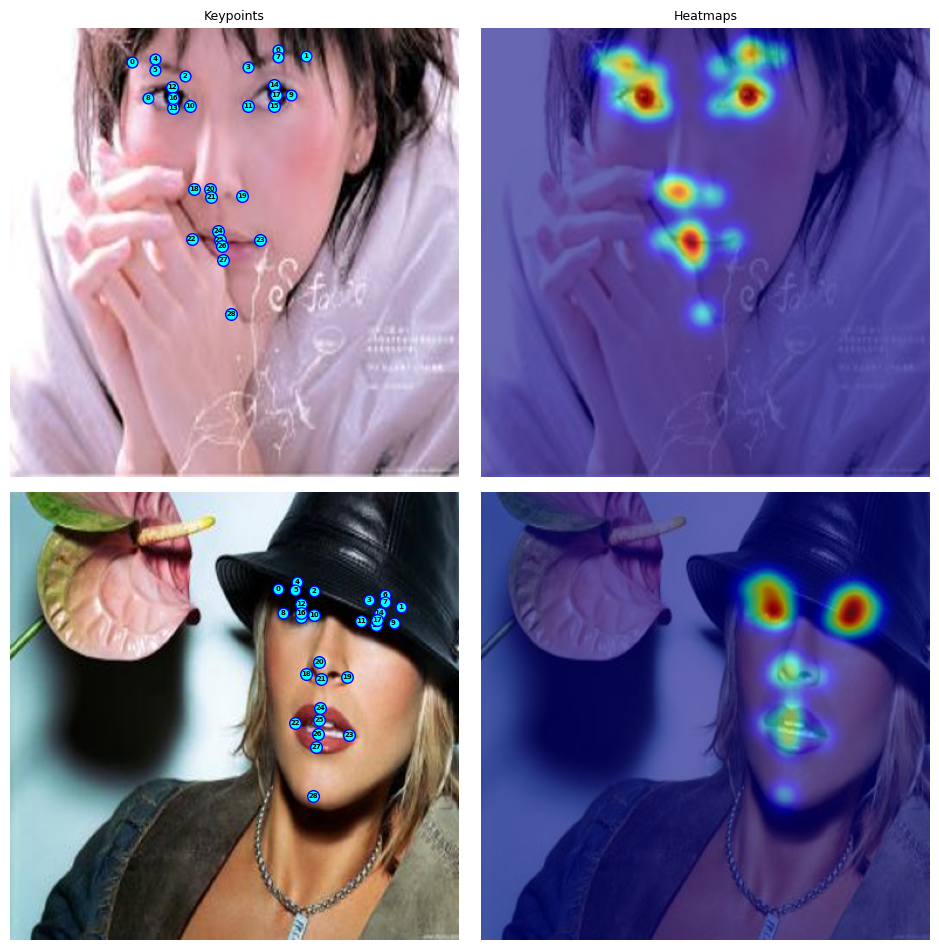

In [207]:
# Visualize ground truth heatmaps and keypoints for the first 2 samples
visualizer.plot_keypoints_heatmaps(images, keypoints, config=config, random=False)

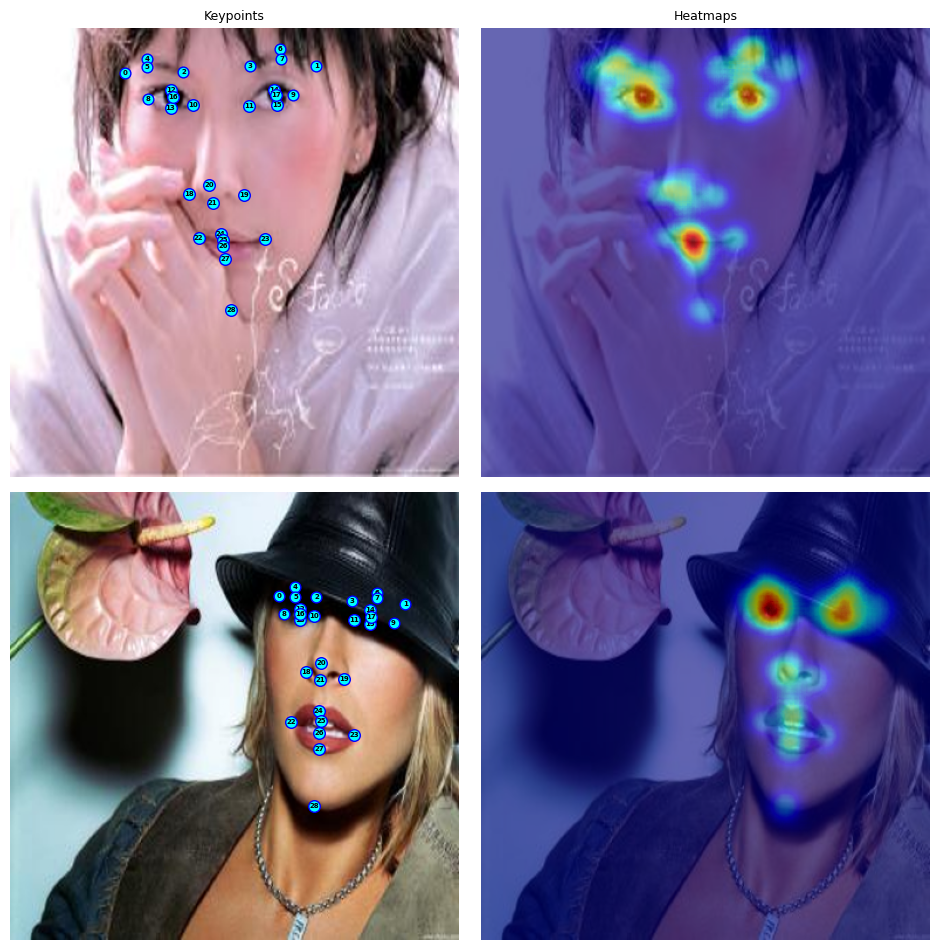

In [206]:
# Visualize predicted heatmaps and keypoints for the first 2 samples
visualizer.plot_keypoints_heatmaps(images, keypoints_pred, heatmaps_pred, random=False)

#### **Keypoint Prediction Visualization**

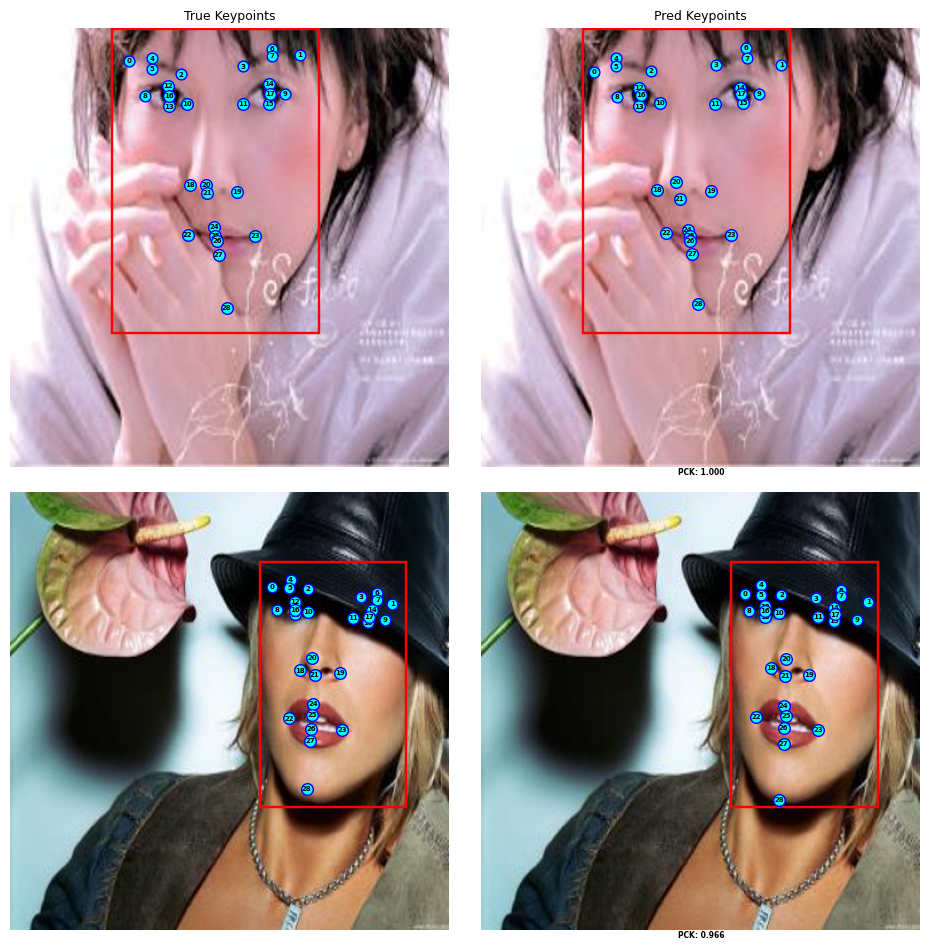

In [43]:
# Visualize both ground truth and predicted keypoints for the first 2 samples
visualizer.plot_keypoints(
    images, keypoints, keypoints_pred, bboxes, diagonals, pck_metric, random=False,
    save_path="FaceLandmarkEstimation_ConvNeXtBase-U-Net_COFW_1.png"
)

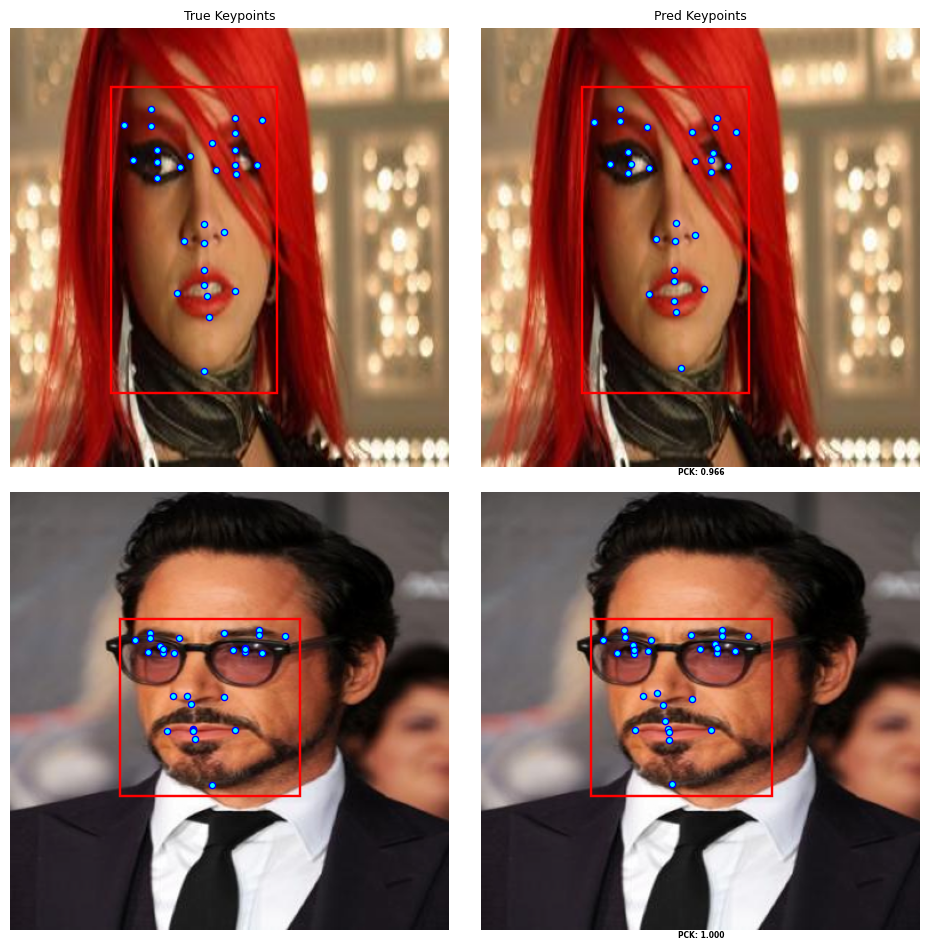

In [93]:
visualizer.plot_keypoints(
    images, keypoints, keypoints_pred, bboxes, diagonals, pck_metric, show_kpts_ids=False,
    save_path="FaceLandmarkEstimation_ConvNeXtBase-U-Net_COFW_2.png"
)

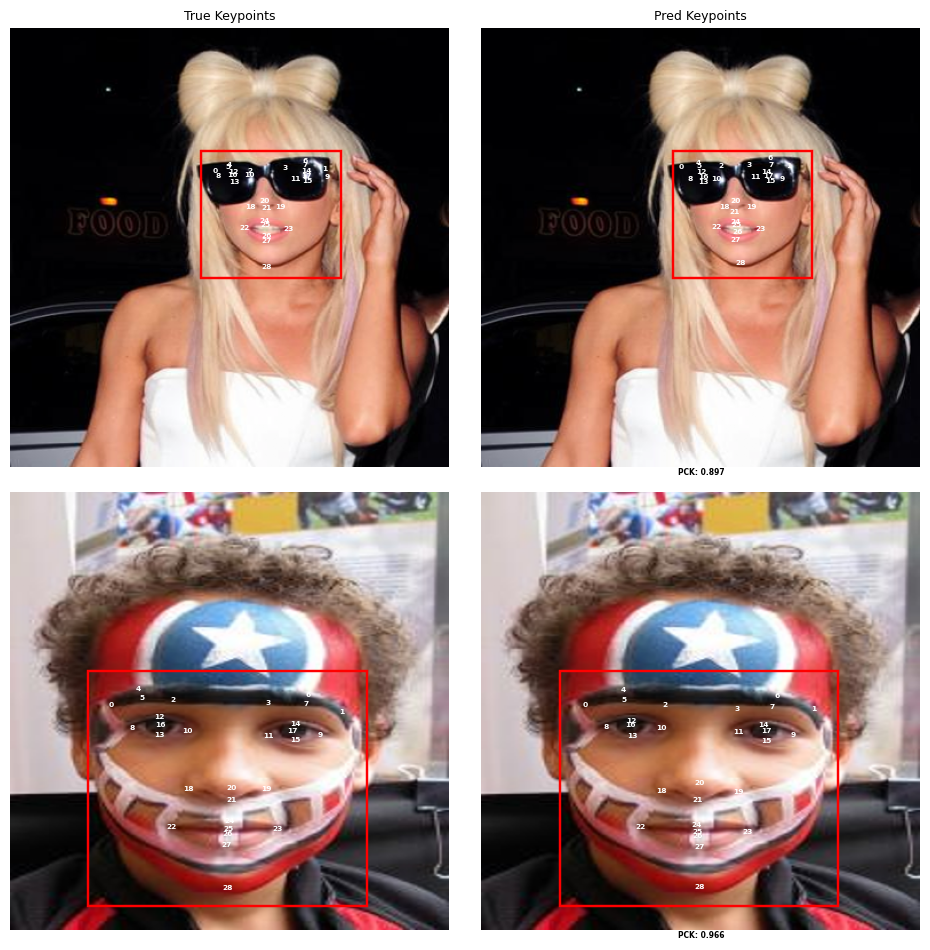

In [134]:
visualizer.plot_keypoints(images, keypoints, keypoints_pred, bboxes, diagonals, pck_metric, show_points=False)

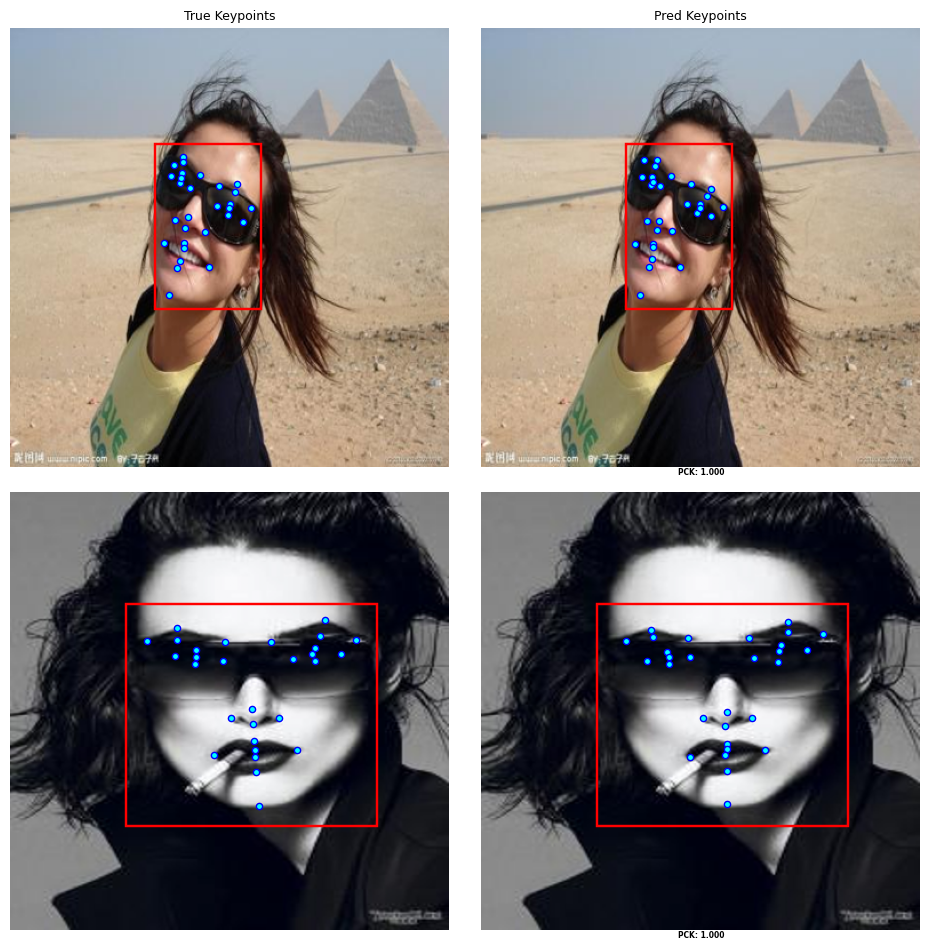

In [ ]:
visualizer.plot_keypoints(images, keypoints, keypoints_pred, bboxes, diagonals, pck_metric, show_kpts_ids=False)

### **Internet Images**

Now, I present how to run inference using images of faces sourced from the internet. This also provides an opportunity to evaluate the model's ability to generalize to unseen data outside the COFW dataset.

In [194]:
image_urls = [
    "https://media.istockphoto.com/id/894361286/photo/mr-cool-himself.jpg?s=612x612&w=0&k=20&c=m9hfsqOm149_SY_C3w79MgwEncru9X61oJwZHec3Xr8=",
    "https://i.guim.co.uk/img/media/043d9d09e2b9de1d3ba478a341051d6bd5f40374/0_24_4500_2700/master/4500.jpg?width=1200&height=900&quality=85&auto=format&fit=crop&s=a7e94899a0238914f25bc077696f427a",
    "https://i1.kknews.cc/CREFlASCvFRqdkuo8xY4VCAvGKNslCWXlS7Prhg/0.jpg",
    "https://media.istockphoto.com/id/1919265357/photo/close-up-portrait-of-confident-businessman-standing-in-office.jpg?s=612x612&w=0&k=20&c=ZXRPTG9VMfYM3XDo1UL9DEpfO8iuGVSsyh8dptfKQsQ="
]

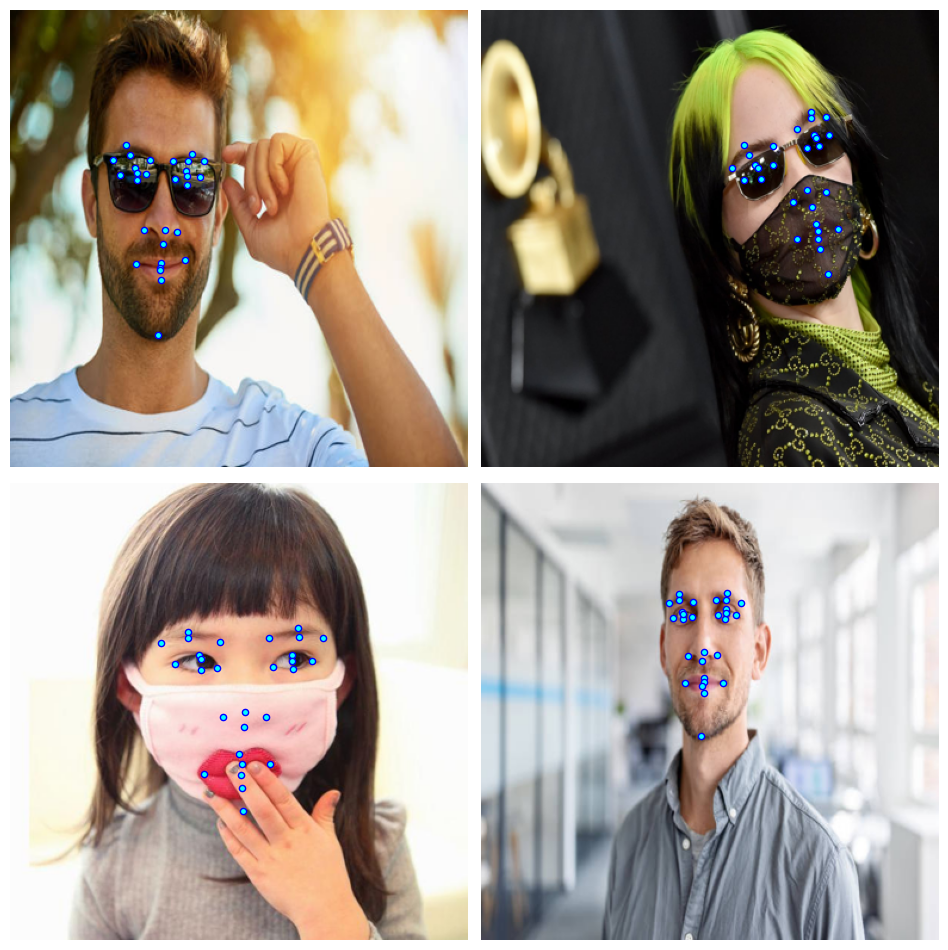

In [ ]:
visualizer.plot_from_urls(
    model, image_urls, config["image_size"], show_kpts_ids=False,
    save_path="FaceLandmarkEstimation_ConvNeXtBase-U-Net_COFW_3.png"
)

## **Conclusion**

The **ConvNeXtBase U-Net** model achieved a **PCK@0.05** of **0.957** on the test set of the **COFW** dataset. This result demonstrates the strong and reliable performance of the model in the task of **face landmark estimation**, even under challenging conditions with severe occlusions, despite the limited number of training images.

It is important to note that all COFW keypoints are annotated (whether visible or occluded), lie within the image boundaries, and that all face images are frontal. For more advanced applications where keypoint **visibility** is explicitly considered, where some landmarks may fall outside the image boundaries, or where faces appear in non-frontal or profile views and even in multi-person scenarios more sophisticated approaches would be required. Furthermore, in larger and more challenging face landmark datasets, the number of annotated landmarks per face typically reaches **100 or more**, which increases task complexity. Nevertheless, for basic scenarios involving occluded frontal faces, the model delivers excellent performance, as evidenced by both the evaluation metrics and inference results.